# Initial Analysis

The purpose of this notebook is to perform an initial analysis of the collected data on edge ML models. We will focus on visualizing the trends in model sizes over the years. Most of the analyses here are just for forming intuitions and guiding further research questions (and also to present to the December 10 meeting).


In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update(
    {
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "legend.fontsize": 12,
        "font.size": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)

/Users/ljvmiranda/Developer/edgeml-survey/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True, parents=True)

In [ ]:
df = load_dataset(
    "ljvmiranda921/edgeml-ltl-survey-annotations",
    split="train",
    # revision="6dae73653bd3397fedc3af0146451a3401059ae7",
).to_pandas()
# Only get those that were marked as relevant
relevance = 4
df = df[df["relevance_score"] >= relevance].reset_index(drop=True)
print(f"Number of relevant entries: {len(df)} (relevance >= {relevance})")

Number of relevant entries: 780 (relevance >= 4)


In [4]:
# Export to CSV to double-check annotations
df.to_csv(DATA_DIR / "edgeml-survey-entries.csv", index=False)

In [5]:
df.columns

Index(['s2_id', 'title', 'authors', 'abstract', 'publication_type', 'venue',
       'date', 'year', 'is_open_access', 'open_access_pdf', 's2_url',
       'citations', 'field_of_study', 'subject_areas', 'application_domain',
       'methods_used', 'deployment_platforms', 'models_released',
       'model_sizes', 'modalities', 'languages_supported', 'relevance_score',
       'relevance_reasoning'],
      dtype='object')

**Research Question**: Did our definition of small (in terms of model parameter size) changed over time? Let's see the distribution of model sizes over the years. To do so:

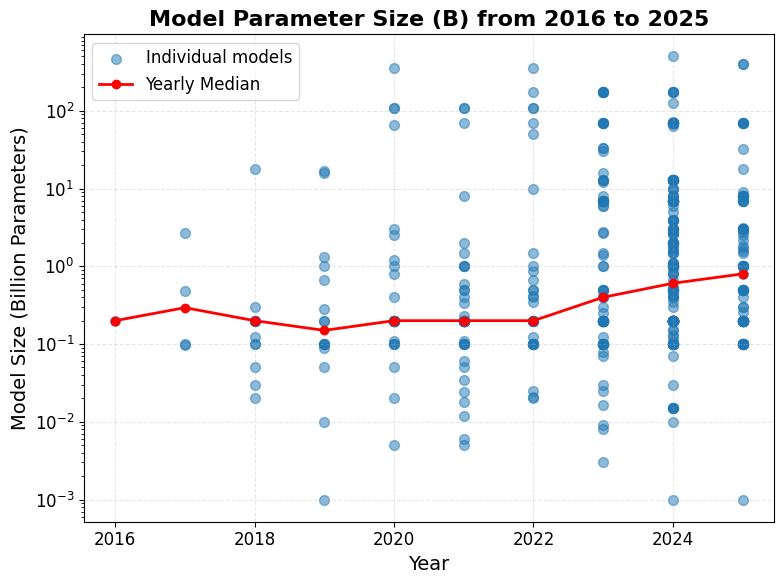

In [55]:
# Did our definition of small (in terms of model parameter size) change over time?
df_plot = df.explode("model_sizes").reset_index(drop=True)
df_plot = df_plot[df_plot["model_sizes"].notna()].copy()
df_plot["model_sizes"] = pd.to_numeric(df_plot["model_sizes"])

yearly_median = df_plot.groupby("year")["model_sizes"].median().reset_index()
yearly_avg = df_plot.groupby("year")["model_sizes"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    df_plot["year"], df_plot["model_sizes"], alpha=0.5, s=50, label="Individual models"
)
ax.plot(
    yearly_median["year"],
    yearly_median["model_sizes"],
    color="red",
    linewidth=2,
    marker="o",
    label="Yearly Median",
)
# ax.plot(
#    yearly_avg["year"],
#    yearly_avg["model_sizes"],
#    color="blue",
#    linewidth=2,
#    marker="o",
#    label="Yearly Average",
# )

ax.set_xlabel("Year")
ax.set_ylabel("Model Size (Billion Parameters)")
ax.set_title("Model Parameter Size (B) from 2016 to 2025", fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

**Research Question**: Is efficient NLP still English-centric?

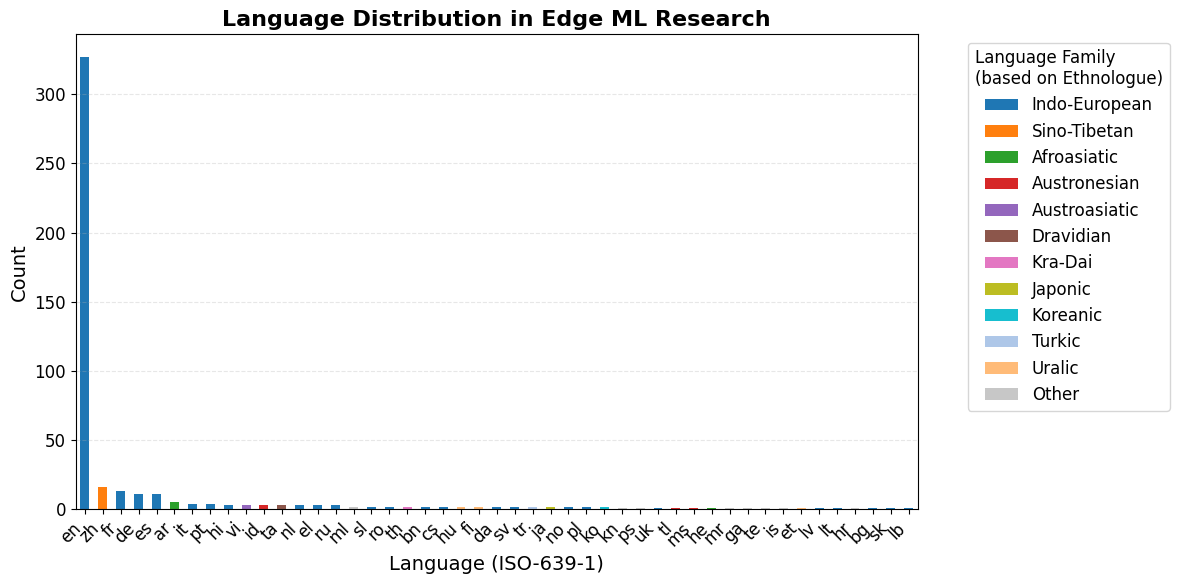

In [48]:
# Is edge ML work English-centric?
import langcodes

df_lang = df.explode("languages_supported").reset_index(drop=True)
df_lang = df_lang[df_lang["languages_supported"].notna()].copy()

programming_languages = {"C++", "Java", "Python", "JavaScript", "C#", "Ruby", "Go"}


def is_valid_language(code):
    if code in programming_languages:
        return False
    try:
        langcodes.Language.get(code)
        return True
    except:
        return False


def get_language_family(code):
    try:
        # fmt: off
        if code in ["en", "de", "fr", "es", "it", "pt", "ru", "hi", "bn", "fa", "el", "pl", "cs", "sv", "no", "da", "nl", "ro", "uk", "bg", "sr", "sl", "sk", "lb", "lt", "lv"]:
            return "Indo-European"
        # fmt: on
        elif code in ["zh"]:
            return "Sino-Tibetan"
        elif code in ["ar", "he"]:
            return "Afroasiatic"
        elif code in ["ja"]:
            return "Japonic"
        elif code in ["ko"]:
            return "Koreanic"
        elif code in ["tr"]:
            return "Turkic"
        elif code in ["fi", "et", "hu"]:
            return "Uralic"
        elif code in ["id", "ms", "tl"]:
            return "Austronesian"
        elif code in ["vi"]:
            return "Austroasiatic"
        elif code in ["ta"]:
            return "Dravidian"
        elif code in ["th"]:
            return "Kra-Dai"
        elif code in ["sw"]:
            return "Niger-Congo"
        else:
            return "Other"
    except:
        return "Other"


df_lang = df_lang[df_lang["languages_supported"].apply(is_valid_language)]
df_lang["language_family"] = df_lang["languages_supported"].apply(get_language_family)
lang_counts = df_lang["languages_supported"].value_counts()

family_colors = {
    "Indo-European": "#1f77b4",
    "Sino-Tibetan": "#ff7f0e",
    "Afroasiatic": "#2ca02c",
    "Austronesian": "#d62728",
    "Austroasiatic": "#9467bd",
    "Dravidian": "#8c564b",
    "Kra-Dai": "#e377c2",
    "Niger-Congo": "#7f7f7f",
    "Japonic": "#bcbd22",
    "Koreanic": "#17becf",
    "Turkic": "#aec7e8",
    "Uralic": "#ffbb78",
    "Other": "#c7c7c7",
}

colors = [family_colors[get_language_family(lang)] for lang in lang_counts.index]

fig, ax = plt.subplots(figsize=(12, 6))
lang_counts.plot(kind="bar", ax=ax, color=colors)
ax.set_xlabel("Language (ISO-639-1)")
ax.set_ylabel("Count")
ax.set_title("Language Distribution in Edge ML Research", fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--", axis="y")
plt.xticks(rotation=45, ha="right")

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=color, label=family)
    for family, color in family_colors.items()
    if any(get_language_family(lang) == family for lang in lang_counts.index)
]
ax.legend(
    handles=legend_elements,
    title="Language Family\n(based on Ethnologue)",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

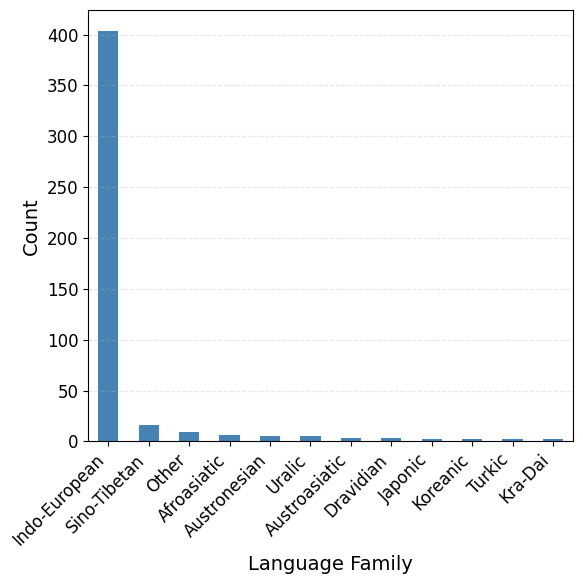

In [49]:
# Language family distribution
family_counts = df_lang["language_family"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
family_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Language Family")
ax.set_ylabel("Count")
# ax.set_title("Language Family Distribution in Edge ML Research", fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--", axis="y")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Research Question:** How does the domain inform the deployment environment for edge ML models? Is there a relationship between where they are deployed (mobile devices, IoT, etc.) and the application domain (healthcare, finance, etc.)?

In [ ]:
import itertools

rows = []
for idx, row in df.iterrows():
    domains = row["application_domain"]
    platforms = row["deployment_platforms"]

    if domains is None or (isinstance(domains, float) and pd.isna(domains)):
        domains = []
    if platforms is None or (isinstance(platforms, float) and pd.isna(platforms)):
        platforms = []

    for domain, platform in itertools.product(domains, platforms):
        rows.append({"application_domain": domain, "deployment_platform": platform})

df_cross = pd.DataFrame(rows)
crosstab = pd.crosstab(df_cross["application_domain"], df_cross["deployment_platform"])
crosstab = crosstab.loc[crosstab.sum(axis=1).sort_values(ascending=False).index]
print(f"\nCross-tabulation shape: {crosstab.shape}")

Created 2331 domain-platform combinations

Cross-tabulation shape: (9, 6)
deployment_platform    Cloud  Laptop/PC  Microcontrollers  Mobile Devices  \
application_domain                                                          
Other                    452         69               127             483   
Healthcare               106         13                40             128   
Smart Cities              67          4                32              86   
Education                 66         11                20              78   
Industrial IoT            38          4                22              37   
Finance                   35          8                 8              32   
Legal                      9          3                 1               7   
Environmental Science      8          2                 1               5   
Agriculture                5          1                 2               5   

deployment_platform    Not Specified  Wearables  
application_domain          

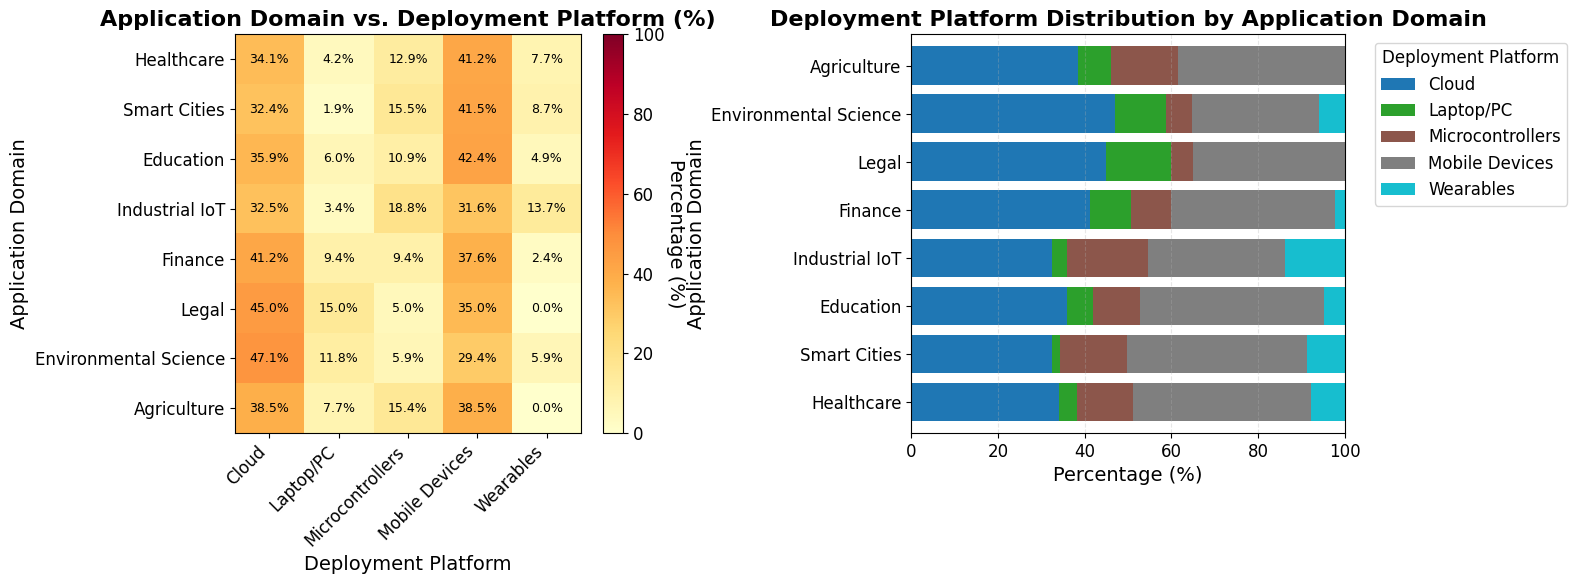

In [ ]:
import numpy as np

crosstab_filtered = crosstab.copy()
# Just include those that reported some domains and platforms
if "Other" in crosstab_filtered.index:
    crosstab_filtered = crosstab_filtered.drop("Other", axis=0)
if "Not Specified" in crosstab_filtered.columns:
    crosstab_filtered = crosstab_filtered.drop("Not Specified", axis=1)
crosstab_pct = crosstab_filtered.div(crosstab_filtered.sum(axis=1), axis=0) * 100
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

im = ax1.imshow(crosstab_pct.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=100)
cbar = plt.colorbar(im, ax=ax1)
cbar.set_label("Percentage (%)", rotation=270, labelpad=15)
for i in range(len(crosstab_pct.index)):
    for j in range(len(crosstab_pct.columns)):
        text = ax1.text(
            j,
            i,
            f"{crosstab_pct.values[i, j]:.1f}%",
            ha="center",
            va="center",
            color="black",
            fontsize=9,
        )

ax1.set_xticks(np.arange(len(crosstab_pct.columns)))
ax1.set_yticks(np.arange(len(crosstab_pct.index)))
ax1.set_xticklabels(crosstab_pct.columns, rotation=45, ha="right")
ax1.set_yticklabels(crosstab_pct.index)
ax1.set_xlabel("Deployment Platform")
ax1.set_ylabel("Application Domain")
ax1.set_title("Application Domain vs. Deployment Platform (%)", fontweight="bold")

crosstab_pct.plot(kind="barh", stacked=True, ax=ax2, colormap="tab10", width=0.8)
ax2.set_xlabel("Percentage (%)")
ax2.set_ylabel("Application Domain")
ax2.set_title(
    "Deployment Platform Distribution by Application Domain", fontweight="bold"
)
ax2.legend(title="Deployment Platform", bbox_to_anchor=(1.05, 1), loc="upper left")
ax2.grid(True, alpha=0.3, linestyle="--", axis="x")
ax2.set_xlim(0, 100)

plt.tight_layout()
plt.show()